In [1]:
!pip install nltk

In [2]:
import nltk

review = "The phone has an amazing camera but terrible battery life."

aspects = {
    "camera": ["camera"],
    "battery": ["battery", "battery life"]
}

positive_words = ["amazing", "excellent", "great", "good"]
negative_words = ["terrible", "bad", "poor", "worst"]

review = review.lower()

for aspect, keywords in aspects.items():

    sentiment = "NEUTRAL"

    for keyword in keywords:

        if keyword in review:

            for word in positive_words:
                if word in review:
                    sentiment = "POSITIVE"

            for word in negative_words:
                if word in review:
                    sentiment = "NEGATIVE"

    print(aspect, ":", sentiment)

camera : NEGATIVE
battery : NEGATIVE


## **Practical 2: spaCy + Aspect Extraction**

In [3]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")

text = "The phone has an amazing camera but terrible battery life."

doc = nlp(text)

for token in doc:

    if token.pos_ == "NOUN":

        print(token.text
              )

phone
camera
battery
life


# **Practical 3: ABSA using Transformer**

In [5]:
!pip install transformers torch

In [6]:
from transformers import pipeline

sentiment = pipeline("sentiment-analysis")

review = """
The camera is amazing but the battery life is terrible.
"""

camera_result = sentiment("The camera is amazing")[0]

battery_result = sentiment("The battery life is terrible")[0]

print("Camera :", camera_result)
print("Battery:", battery_result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Camera : {'label': 'POSITIVE', 'score': 0.9998849630355835}
Battery: {'label': 'NEGATIVE', 'score': 0.9996501207351685}


In [7]:
!pip install nltk scikit-learn pandas seaborn matplotlib joblib

In [14]:
import pandas as pd
import numpy as np
import nltk
import re
import string
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
data = {
    "text": [
        "Python is great for machine learning and AI development",
        "The stock market crashed after poor earnings reports",
        "Manchester United won the Premier League championship",
        "New deep learning model beats GPT 4 on benchmarks",
        "Federal Reserve raises interest rates by 25 basis points",
        "LeBron James scores 40 points in NBA Finals game 7",
        "Tesla launches new self driving software",
        "Gold prices rise amid economic uncertainty",
        "India wins cricket world cup",
        "OpenAI releases new language model"
    ],

    "label": [
        "tech",
        "finance",
        "sports",
        "tech",
        "finance",
        "sports",
        "tech",
        "finance",
        "sports",
        "tech"
    ]
}

df = pd.DataFrame(data)

df.head()

,text,label
0,Python is great for machine learning and AI de...,tech
1,The stock market crashed after poor earnings r...,finance
2,Manchester United won the Premier League champ...,sports
3,New deep learning model beats GPT 4 on benchmarks,tech
4,Federal Reserve raises interest rates by 25 ba...,finance


In [10]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

In [11]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [12]:
def preprocess(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+|#\w+', '', text)

    text = re.sub(r'\d+', 'NUM', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [15]:
df["clean_text"] = df["text"].apply(preprocess)

df[["text","clean_text"]]

,text,clean_text
0,Python is great for machine learning and AI de...,python great machine learning development
1,The stock market crashed after poor earnings r...,stock market crashed poor earnings report
2,Manchester United won the Premier League champ...,manchester united premier league championship
3,New deep learning model beats GPT 4 on benchmarks,new deep learning model beat gpt NUM benchmark
4,Federal Reserve raises interest rates by 25 ba...,federal reserve raise interest rate NUM basis ...
5,LeBron James scores 40 points in NBA Finals ga...,lebron james score NUM point nba final game NUM
6,Tesla launches new self driving software,tesla launch new self driving software
7,Gold prices rise amid economic uncertainty,gold price rise amid economic uncertainty
8,India wins cricket world cup,india win cricket world cup
9,OpenAI releases new language model,openai release new language model


In [16]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=1000
)

X = tfidf.fit_transform(df["clean_text"])

print(X.shape)

(10, 108)


In [17]:
print(tfidf.get_feature_names_out())

['amid' 'amid economic' 'basis' 'basis point' 'beat' 'beat gpt'
 'benchmark' 'championship' 'crashed' 'crashed poor' 'cricket'
 'cricket world' 'cup' 'deep' 'deep learning' 'development' 'driving'
 'driving software' 'earnings' 'earnings report' 'economic'
 'economic uncertainty' 'federal' 'federal reserve' 'final' 'final game'
 'game' 'game num' 'gold' 'gold price' 'gpt' 'gpt num' 'great'
 'great machine' 'india' 'india win' 'interest' 'interest rate' 'james'
 'james score' 'language' 'language model' 'launch' 'launch new' 'league'
 'league championship' 'learning' 'learning development' 'learning model'
 'lebron' 'lebron james' 'machine' 'machine learning' 'manchester'
 'manchester united' 'market' 'market crashed' 'model' 'model beat' 'nba'
 'nba final' 'new' 'new deep' 'new language' 'new self' 'num' 'num basis'
 'num benchmark' 'num point' 'openai' 'openai release' 'point' 'point nba'
 'poor' 'poor earnings' 'premier' 'premier league' 'price' 'price rise'
 'python' 'python great' 

In [18]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,amid,amid economic,basis,basis point,beat,beat gpt,benchmark,championship,crashed,crashed poor,...,stock market,tesla,tesla launch,uncertainty,united,united premier,win,win cricket,world,world cup
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301511,0.301511,...,0.301511,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.000000,0.271647,0.271647,0.271647,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.264667,0.264667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [19]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["label"])

print(y)

[2 0 1 2 0 1 2 0 1 2]


In [20]:
encoder.classes_

array(['finance', 'sports', 'tech'], dtype=object)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ** Train Multiple Models**
**1. Naive Bayes**

In [22]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

**2. Logistic Regression**

In [23]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

**3. Linear SVM**

In [24]:
svm = LinearSVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print(classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [25]:
# Compare the model using the cross validation
models = {

    "Naive Bayes": MultinomialNB(),

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Linear SVM":
        LinearSVC()
}

In [26]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=3,
        scoring='f1_macro'
    )

    print(
        f"{name}: "
        f"{scores.mean():.3f}"
    )

Naive Bayes: 0.185
Logistic Regression: 0.241
Linear SVM: 0.241


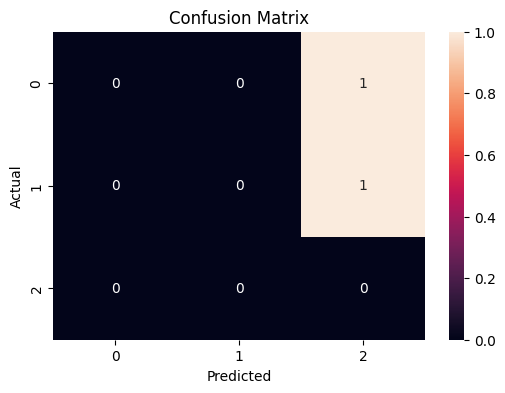

In [27]:
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
new_text = [
    "OpenAI launches powerful GPT model"
]

In [29]:
clean_text = preprocess(new_text[0])

vector = tfidf.transform([clean_text])

prediction = lr.predict(vector)

label = encoder.inverse_transform(prediction)

print(label[0])

tech


In [30]:
samples = [

    "India wins cricket series",

    "Stock market falls sharply",

    "Google launches AI model"
]

In [31]:
for sentence in samples:

    clean = preprocess(sentence)

    vector = tfidf.transform([clean])

    pred = lr.predict(vector)

    label = encoder.inverse_transform(pred)

    print(sentence, "->", label[0])

India wins cricket series -> tech
Stock market falls sharply -> tech
Google launches AI model -> tech
